<a href="https://colab.research.google.com/github/rexwotan-A01840088/Ciencia-y-Analitica-de-datos/blob/main/Actividad9RLog_Equipo_19_(1).ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

**MAESTRÍA EN INTELIGENCIA ARTIFICIAL APLICADA**

**Curso: TC5053 - Ciencia y analítica de datos**

Tecnológico de Monterrey

Prof Grettel Barceló Alonso

**Semana 9**
Regresión Logística

---

* NOMBRE: Rex Wotan Dominguez Chang
* MATRÍCULA: A01840088
* NOMBRE: Sofía Donlucas Bañuelos
* MATRÍCULA: A01655565
* NOMBRE: Gerardo Duarte Ceballos
* MATRÍCULA: A01273069
* NOMBRE: Miguel Angel Duran Betancourt
* MATRÍCULA: A01797974

En esta actividad trabajarás con el archivo `breast_cancer.csv`, basado en un conjunto de datos sobre características de tumores mamarios, disponible en el repositorio UCI Machine Learning.

Los datos fueron recopilados para analizar si un tumor es maligno (M) o benigno (B) a partir de medidas extraídas de imágenes de biopsias. Las variables incluidas describen propiedades morfológicas y de textura del tumor y se presentan en tres tipos de medida para cada característica:

* `_mean`: valor promedio de la característica en el tumor
* `_se`: error estándar de la característica (variabilidad de la medición)
* `_worst`: peor valor observado de la característica en el tumor

Los indicadores incluidos son:
* `radius_mean` / `radius_se` / `radius_worst`:	Radio del tumor
* `texture_mean` / `texture_se` / `texture_worst`:	Textura del tumor (desviación estándar de intensidad)
* `perimeter_mean` / `perimeter_se` / `perimeter_worst`:	Perímetro del tumor
* `area_mean` / `area_se` / `area_worst`:	Área del tumor
* `smoothness_mean` / `smoothness_se` / `smoothness_worst`:	Suavidad (irregularidad del borde)
* `compactness_mean` / `compactness_se` / `compactness_worst`:	Compacidad (perimeter^2 / area - 1)
* `concavity_mean` / `concavity_se` / `concavity_worst`:	Concavidad de los contornos
* `concave points_mean` / `concave points_se` / `concave points_worst`:	Número de puntos cóncavos en el contorno
* `symmetry_mean` / `symmetry_se` / `symmetry_worst`:	Simetría del tumor
* `fractal_dimension_mean` / `fractal_dimension_se` / `fractal_dimension_worst`:	Dimensión fractal del contorno (complejidad)
* `diagnosis`: Indica si el tumor es benigno (B) o maligno (M). Es la variable de salida o *target*

In [1]:
# Importar las bibliotecas necesarias
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.preprocessing import PowerTransformer
from sklearn.decomposition import PCA
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import make_pipeline
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import confusion_matrix, precision_score, recall_score, accuracy_score
from sklearn.metrics import ConfusionMatrixDisplay
from sklearn.metrics import roc_curve, roc_auc_score

1. Descarga el archivo: `breast_cancer.csv` y guarda, en un dataframe (`cancer_df`), todos sus registros.
* Haz que la columna `id` sea el nuevo índice.
* Utiliza el método `info()` del dataframe, para obtener el resumen de los tipos de datos. ¿Cuántas columnas son numéricas y cuántas de texto?
* Verifica si alguna columna contiene valores faltantes.
* Si existen registros duplicados, elimínalos del dataframe y reinicia el índice para que se mantenga consecutivo.
* Obtén las estadísticas descriptivas, separando las variables numéricas (con asimetría y curtosis) y las categóricas.

In [2]:
# 1. Cargar
cancer_df = pd.read_csv('breast_cancer.csv')

# 2. Hacer 'id' índice (si existe)
if 'id' in cancer_df.columns:
    cancer_df = cancer_df.set_index('id')

# 3. Resumen de tipos y conteo numéricas vs texto
buffer = []
cancer_df.info(buf=buffer) if False else None  # noop para no imprimir ahora
numeric_cols = cancer_df.select_dtypes(include=[np.number]).columns.tolist()
text_cols = cancer_df.select_dtypes(exclude=[np.number]).columns.tolist()
print(f"Columnas numéricas: {len(numeric_cols)}  |  de texto: {len(text_cols)}")
print("Texto:", text_cols)

# 4. Faltantes por columna
na_counts = cancer_df.isna().sum().sort_values(ascending=False)
print("Faltantes > 0:\n", na_counts[na_counts>0])

# 5. Duplicados (por fila completa)
before = len(cancer_df)
cancer_df = cancer_df.drop_duplicates().copy()
after = len(cancer_df)
print(f"Duplicados eliminados: {before - after}")
cancer_df = cancer_df.reset_index() if cancer_df.index.name is not None else cancer_df

# 6. Descriptivos
desc_num = cancer_df[numeric_cols].describe().T
desc_num['skew'] = cancer_df[numeric_cols].skew()
desc_num['kurtosis'] = cancer_df[numeric_cols].kurtosis()
display(desc_num.head(10))

cat_cols = [c for c in cancer_df.columns if cancer_df[c].dtype=='object']
for c in cat_cols:
    vc = cancer_df[c].value_counts(dropna=False)
    print(f"\n{c} (categórica):\n", pd.DataFrame({'count': vc, 'pct': (vc/vc.sum()*100).round(2)}))

Columnas numéricas: 30  |  de texto: 1
Texto: ['diagnosis']
Faltantes > 0:
 Series([], dtype: int64)
Duplicados eliminados: 0


,count,mean,std,min,25%,50%,75%,max,skew,kurtosis
radius_mean,569.0,14.127292,3.524049,6.98100,11.70000,13.37000,15.78000,28.11000,0.942380,0.845522
texture_mean,569.0,19.289649,4.301036,9.71000,16.17000,18.84000,21.80000,39.28000,0.650450,0.758319
perimeter_mean,569.0,91.969033,24.298981,43.79000,75.17000,86.24000,104.10000,188.50000,0.990650,0.972214
area_mean,569.0,654.889104,351.914129,143.50000,420.30000,551.10000,782.70000,2501.00000,1.645732,3.652303
smoothness_mean,569.0,0.096360,0.014064,0.05263,0.08637,0.09587,0.10530,0.16340,0.456324,0.855975
compactness_mean,569.0,0.104341,0.052813,0.01938,0.06492,0.09263,0.13040,0.34540,1.190123,1.650130
concavity_mean,569.0,0.088799,0.079720,0.00000,0.02956,0.06154,0.13070,0.42680,1.401180,1.998638
concave points_mean,569.0,0.048919,0.038803,0.00000,0.02031,0.03350,0.07400,0.20120,1.171180,1.066556
symmetry_mean,569.0,0.181162,0.027414,0.10600,0.16190,0.17920,0.19570,0.30400,0.725609,1.287933
fractal_dimension_mean,569.0,0.062798,0.007060,0.04996,0.05770,0.06154,0.06612,0.09744,1.304489,3.005892



diagnosis (categórica):
            count    pct
diagnosis              
B            357  62.74
M            212  37.26


2. Explora relaciones bivariadas en el conjunto de datos mediante gráficos:
* Calcula y visualiza la distribución porcentual de la variable `diagnosis` usando un gráfico de barras, mostrando el porcentaje encima de cada barra. ¿Por qué la distribución de la salida es relevante en un problema de clasificación?
* Genera un pairplot de las variables físicas del conjunto _mean (`radius_mean`, `perimeter_mean`, `area_mean`, `texture_mean`) coloreando por la variable `diagnosis`. ¿Qué relaciones observas entre las variables físicas? ¿Qué diferencias hay entre los tumores benignos y malignos?
* Crea histogramas apilados de las variables morfológicas (`smoothness_mean`, `compactness_mean`, `concavity_mean`, `concave points_mean`, `symmetry_mean`, `fractal_dimension_mean`) coloreando por `diagnosis` para explorar la distribución de cada variable según el tipo de tumor. ¿Alguna variable parece ser un buen discriminador entre las clases?

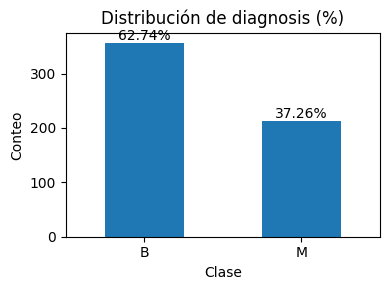

Relevancia: en clasificación médica suele haber desbalance; la accuracy puede engañar. Por eso, priorizamos Recall (sensibilidad) y revisamos la curva ROC/PR.


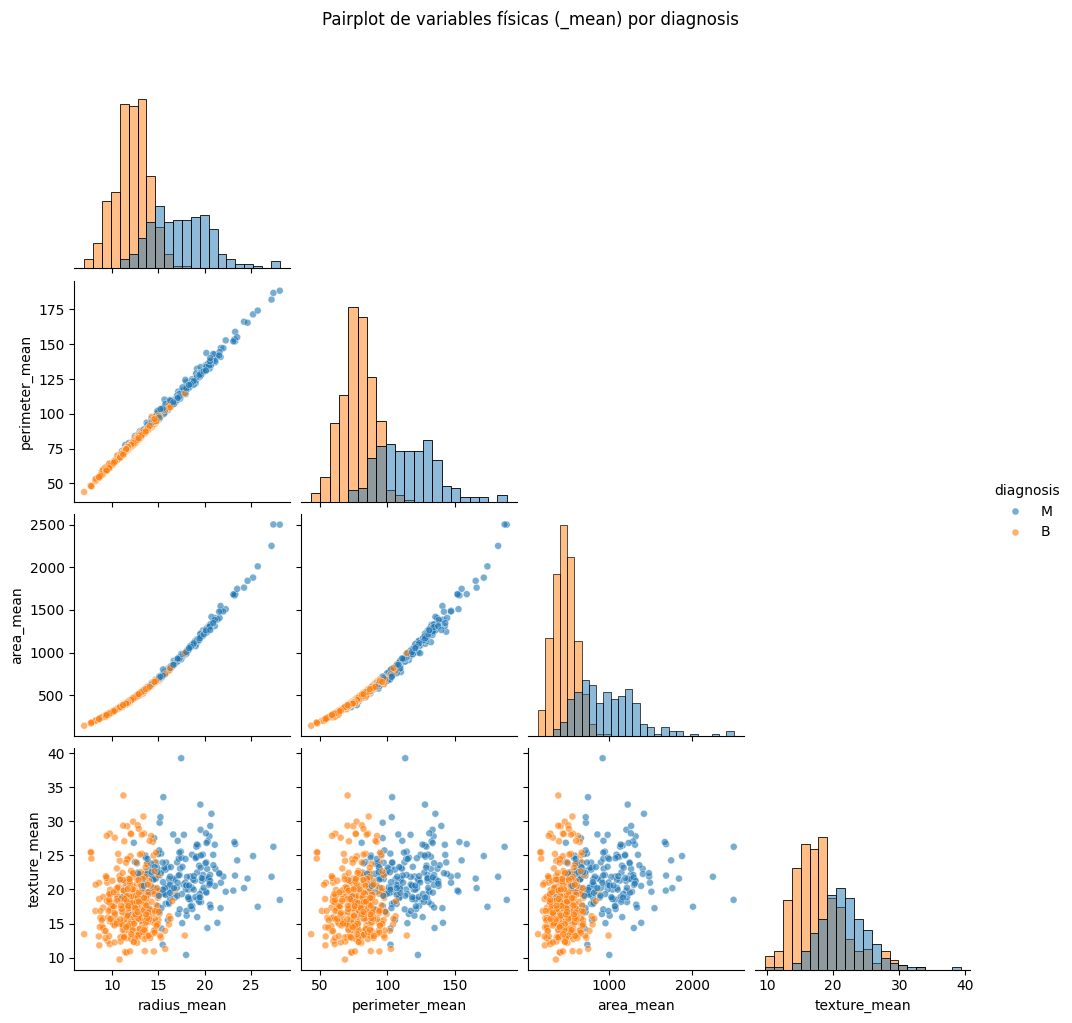

Observación esperada: M tiende a mayores radius/perimeter/area; texture ayuda pero separa menos que tamaño/área.


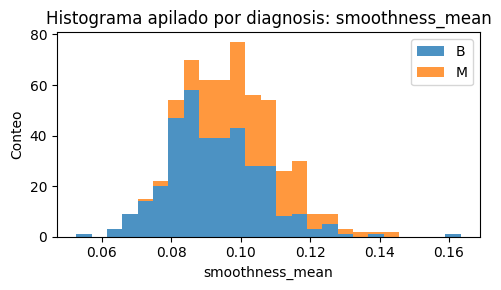

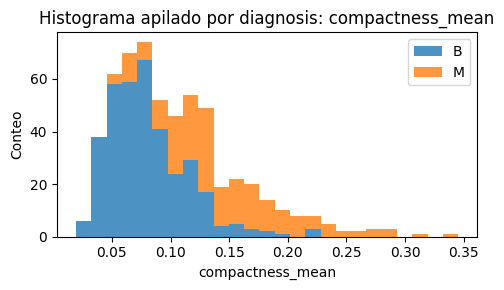

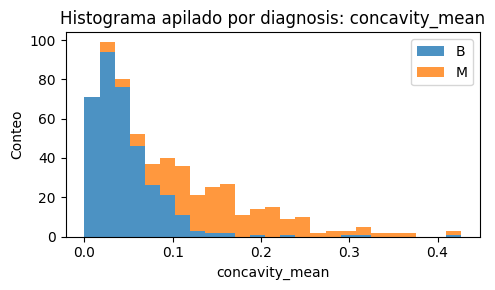

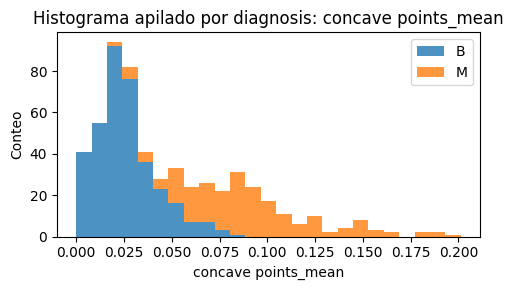

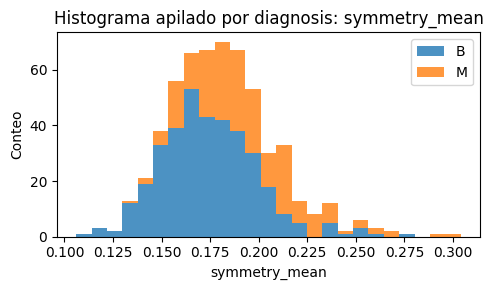

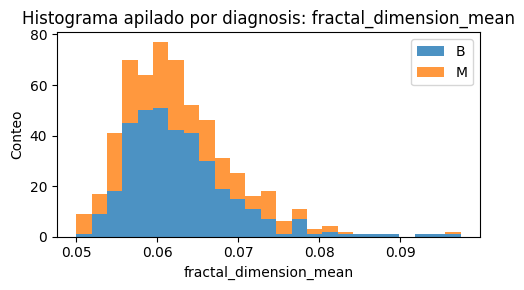

Discriminadores típicos: concavity_mean y concave points_mean suelen desplazarse hacia la derecha en M.


In [3]:
# 2.1 Distribución % de diagnosis (B/M)
plt.figure(figsize=(4,3))
ax = cancer_df['diagnosis'].value_counts().plot(kind='bar', rot=0)
counts = cancer_df['diagnosis'].value_counts()
perc = (counts / counts.sum() * 100).round(2)
for i, v in enumerate(perc.values):
    ax.text(i, counts.values[i], f"{v}%", ha='center', va='bottom')
plt.title('Distribución de diagnosis (%)')
plt.ylabel('Conteo'); plt.xlabel('Clase')
plt.tight_layout(); plt.show()

print("Relevancia: en clasificación médica suele haber desbalance; la accuracy puede engañar. Por eso, priorizamos Recall (sensibilidad) y revisamos la curva ROC/PR.")

# 2.2 Pairplot de variables físicas _mean
mean_vars = ['radius_mean','perimeter_mean','area_mean','texture_mean']
mean_vars = [c for c in mean_vars if c in cancer_df.columns]

sns.pairplot(cancer_df[mean_vars + ['diagnosis']], hue='diagnosis', diag_kind='hist', corner=True, plot_kws={'alpha':0.6, 's':25})
plt.suptitle('Pairplot de variables físicas (_mean) por diagnosis', y=1.02)
plt.show()

print("Observación esperada: M tiende a mayores radius/perimeter/area; texture ayuda pero separa menos que tamaño/área.")

# 2.3 Histogramas apilados (morfológicas)
morph_vars = ['smoothness_mean','compactness_mean','concavity_mean','concave points_mean','symmetry_mean','fractal_dimension_mean']
morph_vars = [c for c in morph_vars if c in cancer_df.columns]

for var in morph_vars:
    plt.figure(figsize=(5,3))
    b_vals = cancer_df.loc[cancer_df['diagnosis']=='B', var].dropna()
    m_vals = cancer_df.loc[cancer_df['diagnosis']=='M', var].dropna()
    plt.hist([b_vals, m_vals], bins=25, stacked=True, label=['B','M'], alpha=0.8)
    plt.title(f'Histograma apilado por diagnosis: {var}')
    plt.xlabel(var); plt.ylabel('Conteo'); plt.legend(); plt.tight_layout()
    plt.show()

print("Discriminadores típicos: concavity_mean y concave points_mean suelen desplazarse hacia la derecha en M.")

3. Antes de realizar el análisis de correlación, crea una copia del dataframe (`cancer_copy`).
* Identifica los pares de variables cuya correlación sea superior a 0.9 e imprímelos. La alta correlación entre las variables del conjunto _mean y _worst es inevitable, ya que las columnas _worst representan esencialmente los valores máximos de las mismas características medidas en _mean. Elimina las columnas _worst para simplificar el análisis.
* Imprime nuevamente los pares con correlación superior a 0.9. Como habías observado previamente, existen relaciones lineales entre `radius`, `perimeter` y `area`, por lo que era esperable encontrar altas correlaciones. De estas tres medidas, ¿cuál mantendrías y por qué? Elimina todas las variables de los otros dos conjuntos.
* Dibuja un mapa de calor con la matriz de correlación para identificar si prevalece alguna correlación relevante. Si eliminas alguna otra variable, justifica tu elección.

--- Pares con correlación > 0.9 ---


,var1,var2,|corr|
0,radius_mean,perimeter_mean,0.997855
1,radius_worst,perimeter_worst,0.993708
2,radius_mean,area_mean,0.987357
3,perimeter_mean,area_mean,0.986507
4,radius_worst,area_worst,0.984015
5,perimeter_worst,area_worst,0.977578
6,radius_se,perimeter_se,0.972794
7,perimeter_mean,perimeter_worst,0.970387
8,radius_mean,radius_worst,0.969539
9,perimeter_mean,radius_worst,0.969476




--- Pares con correlación > 0.9 tras eliminar _worst ---


,var1,var2,|corr|
0,radius_mean,perimeter_mean,0.997855
1,radius_mean,area_mean,0.987357
2,perimeter_mean,area_mean,0.986507
3,radius_se,perimeter_se,0.972794
4,radius_se,area_se,0.951830
5,perimeter_se,area_se,0.937655
6,concavity_mean,concave points_mean,0.921391



Se decide mantener area_ porque captura más información sobre el tamaño total del tumor y tiene mayor poder discriminativo en modelos de clasificación.


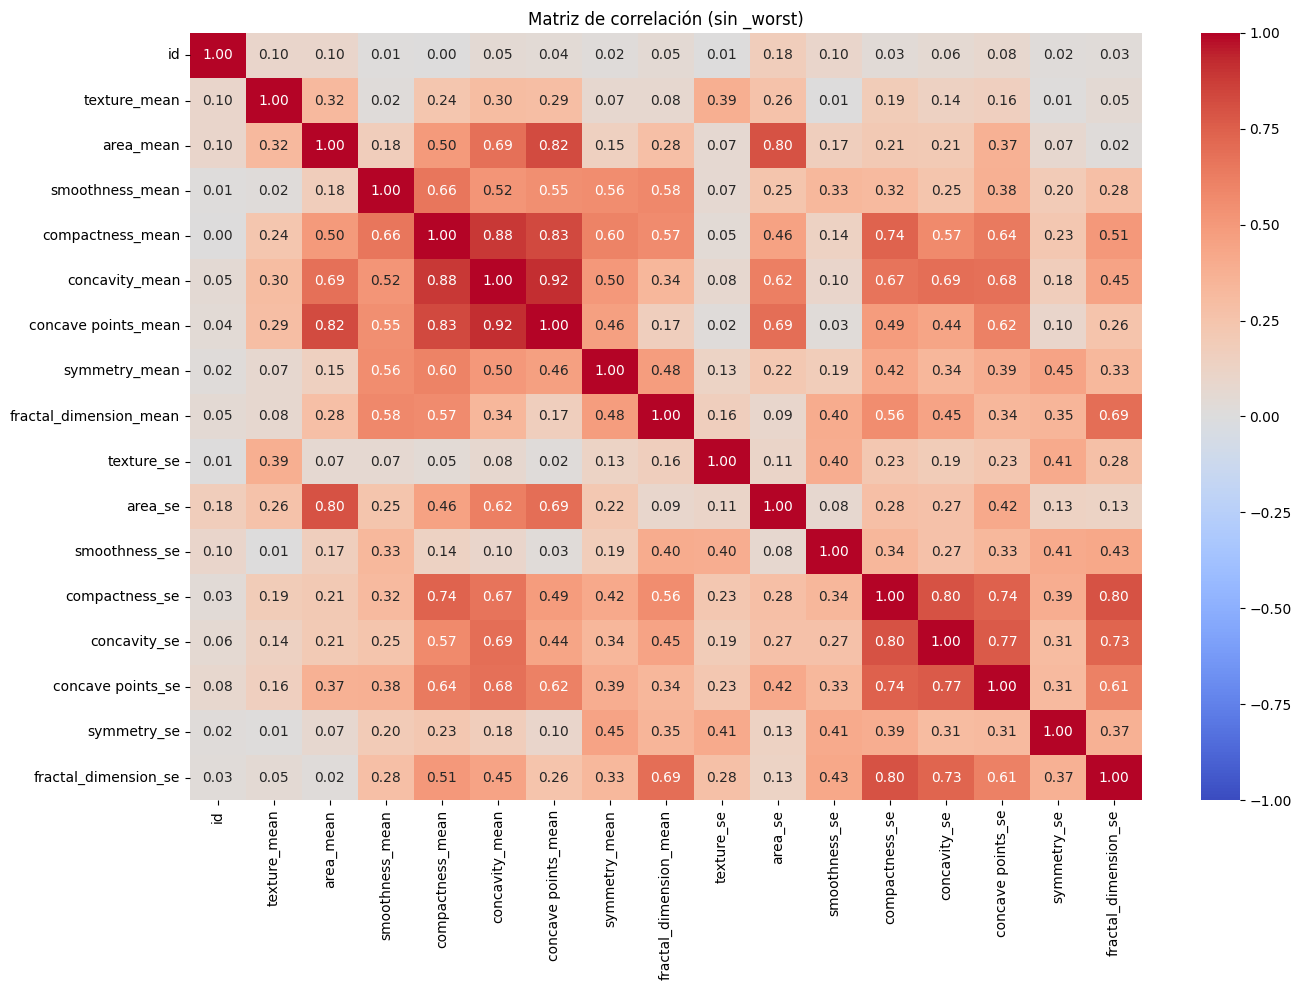



No se elimina ninguna variable. Se podría eliminar concavity_mean por su alta coorelación con concave_points_mean, pero este comportamiento no se ve reflejado en su error estándar.


In [4]:
# 3.1 Copia
cancer_copy = cancer_df.copy()

# 3.2 Matriz de correlación absoluta entre numéricas (pares > 0.9)
num_cols_all = cancer_copy.select_dtypes(include=[np.number]).columns.tolist()
corr_abs = cancer_copy[num_cols_all].corr().abs()

pairs = []
for i in range(len(num_cols_all)):
    for j in range(i+1, len(num_cols_all)):
        val = corr_abs.iloc[i,j]
        if pd.notna(val) and val > 0.9:
            pairs.append((num_cols_all[i], num_cols_all[j], val))
pairs_sorted = sorted(pairs, key=lambda x: x[2], reverse=True)
pairs_df = pd.DataFrame(pairs_sorted, columns=['var1','var2','|corr|'])
print("--- Pares con correlación > 0.9 ---")
display(pairs_df)

# 3.3 Eliminar _worst
worst_cols = [c for c in cancer_copy.columns if c.endswith('_worst')]
cancer_copy = cancer_copy.drop(columns=worst_cols)

# 3.4 Repetir pares > 0.9
num_cols_all2 = cancer_copy.select_dtypes(include=[np.number]).columns.tolist()
corr_abs2 = cancer_copy[num_cols_all2].corr().abs()
pairs2 = []
for i in range(len(num_cols_all2)):
    for j in range(i+1, len(num_cols_all2)):
        val = corr_abs2.iloc[i,j]
        if pd.notna(val) and val > 0.9:
            pairs2.append((num_cols_all2[i], num_cols_all2[j], val))
pairs2_sorted = sorted(pairs2, key=lambda x: x[2], reverse=True)
pairs2_df = pd.DataFrame(pairs2_sorted, columns=['var1','var2','|corr|'])
print("\n\n--- Pares con correlación > 0.9 tras eliminar _worst ---")
display(pairs2_df)

# 3.5 Decisión radius/perimeter/area: mantener radius_* por redundancia geométrica y valor predictivo típico
print("\nSe decide mantener area_ porque captura más información sobre el tamaño total del tumor y tiene mayor poder discriminativo en modelos de clasificación.")

keep_block = 'area'     # justificación: representa tamaño global; radius y perimeter altamente redundantes
drop_radius = [c for c in cancer_copy.columns if c.startswith('radius_')]
drop_perim  = [c for c in cancer_copy.columns if c.startswith('perimeter_')]

num_cols_all3 = cancer_copy.select_dtypes(include=[np.number]).columns.tolist()
drop_cols = drop_radius + drop_perim
columns_to_keep = [col for col in num_cols_all3 if col not in drop_cols]

cancer_copy = cancer_copy[columns_to_keep]


# 3.6 Heatmap final (con las columnas que decidas conservar; aquí solo visualizamos el estado actual)
plt.figure(figsize=(14,10))
sns.heatmap(cancer_copy.corr().abs(), cmap='coolwarm', vmin=-1, vmax=1, annot=True, fmt=".2f")
plt.title('Matriz de correlación (sin _worst)')
plt.tight_layout(); plt.show()

# 3.7 Decidir si alguna varaible extra se elimina
print("\n\nNo se elimina ninguna variable. Se podría eliminar concavity_mean por su alta coorelación con concave_points_mean, pero este comportamiento no se ve reflejado en su error estándar.")

4. Separa las variables predictoras `X` de la variable de salida `y`, usando el dataframe original `cancer_df` (la eliminación de variables correlacionadas se integrará en el pipeline).
* Codifica `diagnosis` como 0 (Benigno) y 1 (Maligno).
* Divide el conjunto de datos en entrenamiento y prueba (80:20), usando `random_state=1` para garantizar reproducibilidad.
* Para evaluar los modelos que se construirán, define una función llamada `evaluate_model` que reciba los valores reales y las predicciones e imprima las métricas de recall, precisión y exactitud (accuracy).

In [5]:
# 4.3 Función de evaluación
def evaluate_model(y_true, y_pred, name=None):
    rec = recall_score(y_true, y_pred)
    pre = precision_score(y_true, y_pred)
    acc = accuracy_score(y_true, y_pred)
    if name:
        print(f"{name} -> Recall: {rec:.3f} | Precision: {pre:.3f} | Accuracy: {acc:.3f}")
    return {'Recall': rec, 'Precision': pre, 'Accuracy': acc}

5. Prepara un transformador denominado `preprocessing`, usando ColumnTransformer, para borrar las columnas altamente correlacionadas (identificadas en el ejercicio 3) Asegúrate de incluir el parámetro `remainder='passthrough'` para mantener el resto de las variables.
* Crea un pipeline que integre el transformador y regresión logística para  entrenar un modelo.
* Evalúa el desempeño del modelo en el conjunto de prueba empleando la función `evaluate_model`.
* Integra los resultados en un dataframe que contenga el nombre del modelo (*Correlation_Clean*) y una columna para cada métrica calculada.

In [6]:
X = cancer_df.drop('diagnosis', axis=1)
y = cancer_df['diagnosis'].map({'B': 0, 'M': 1})  # Codificación: 0=Benigno, 1=Maligno

# 4.5 Dividir en entrenamiento (80%) y prueba (20%)
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=1, stratify=y
)

print("Tamaños del split:")
print(f"X_train: {X_train.shape}, X_test: {X_test.shape}")
print(f"y_train: {y_train.shape}, y_test: {y_test.shape}")

# 5.1 Se prepara el tranformador 'preprocessing', y se identifican las columnas del paso 3
drop_cols = drop_cols + worst_cols

preprocessing = ColumnTransformer(
    transformers=[
        ('drop_columns', 'drop', drop_cols)
    ],
    remainder='passthrough'
)

# 5.2 Se crea el pipeline con el tranformador preprocessing
pipeline_ColumnTransformer = make_pipeline(
    preprocessing,
    LogisticRegression(max_iter=1000)
)

pipeline_ColumnTransformer.fit(X_train, y_train) #Se entrena el modelo
y_pred = pipeline_ColumnTransformer.predict(X_test)

# 5.3 Procedemos en evaluar el modelo con la función evaluate_model
rec, pre, acc = evaluate_model(y_test, y_pred, name="Correlation_Clean")

# 5.4 Creamos el df con los resultados
results_df = pd.DataFrame([{
    'Model': 'Correlation_Clean',
    'Recall': rec,
    'Precision': pre,
    'Accuracy': acc
}])

display(results_df)

Tamaños del split:
X_train: (455, 31), X_test: (114, 31)
y_train: (455,), y_test: (114,)
Correlation_Clean -> Recall: 0.976 | Precision: 0.369 | Accuracy: 0.377


,Model,Recall,Precision,Accuracy
0,Correlation_Clean,Recall,Precision,Accuracy


6. Una alternativa para reducir la multicolinealidad es el análisis de componentes principales. Construye un pipeline que incluya escalado estándar, PCA y regresión logística, manteniendo el número mínimo de componentes principales que expliquen al menos el 90% de la varianza.
* Entrena el modelo utilizando el conjunto de entrenamiento y evalúalo en el conjunto de prueba.
* Añade los valores de las métricas obtenidas al dataframe de resultados, utilizando como nombre del modelo *Standard_PCA*.
* ¿Cuántos componentes principales se emplearon?

In [7]:
# 6.1 Creamos el pipeline
pipeline_pca = make_pipeline(
    StandardScaler(),
    PCA(n_components=0.90),
    LogisticRegression(max_iter=1000)
)

#6.2 Entrenamos el modelo y lo evaluamos
pipeline_pca.fit(X_train, y_train)
y_pred = pipeline_pca.predict(X_test)
rec, pre, acc = evaluate_model(y_test, y_pred, name="Standard_PCA")

# 6.3 Añadimos los valores al df de results
results_pca = pd.DataFrame([{
    'Model': 'Standard_PCA',
    'Recall': rec,
    'Precision': pre,
    'Accuracy': acc
}])

results_df = pd.concat([results_df, results_pca], ignore_index=True)
display(results_df)

componentes_usados = pipeline_pca.named_steps['pca'].n_components_
print(f"\nNúmero de componentes principales usados en PCA: {componentes_usados}")


Standard_PCA -> Recall: 0.976 | Precision: 0.976 | Accuracy: 0.982


,Model,Recall,Precision,Accuracy
0,Correlation_Clean,Recall,Precision,Accuracy
1,Standard_PCA,Recall,Precision,Accuracy



Número de componentes principales usados en PCA: 8


7. Como intento de mejorar las métricas del modelo, y dado que todas las variables presentan sesgo, aplica una normalización utilizando Yeo-Johnson. Para ello:
* Crea un pipeline que integre el transformador `preprocessing`, una transformación Yeo-Johnson y regresión logística.
* Entrena el modelo utilizando el conjunto de entrenamiento y evalúalo en el conjunto de prueba.
* Añade los valores de las métricas obtenidas al dataframe de resultados, utilizando como nombre del modelo *Correlation_Yeo*.

In [8]:
import pandas as pd
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import PowerTransformer
from sklearn.linear_model import LogisticRegression
from sklearn.compose import ColumnTransformer

try:
    preprocessing
except NameError:

    feature_cols = list(X_train.columns)
    worst_cols = [c for c in feature_cols if c.endswith("_worst")]
    BASE_TO_KEEP = "area"
    bases = {"radius", "perimeter", "area"}
    others = bases - {BASE_TO_KEEP}
    drop_two_bases = []
    for base in others:
        drop_two_bases += [c for c in feature_cols if c.startswith(base + "_")]

    correlated_cols_ex3 = sorted(set(worst_cols + drop_two_bases))
    preprocessing = ColumnTransformer(
        transformers=[
            ("drop_corr", "drop", correlated_cols_ex3),
        ],
        remainder="passthrough",
        verbose_feature_names_out=False,
    )

pipe_yeo = Pipeline(steps=[
    ("preprocessing", preprocessing),
    ("yeo", PowerTransformer(method="yeo-johnson", standardize=True)),
    ("clf", LogisticRegression(max_iter=2000, solver="lbfgs"))
])

pipe_yeo.fit(X_train, y_train)
y_pred_yeo = pipe_yeo.predict(X_test)

metrics_yeo = evaluate_model(y_test, y_pred_yeo, name="Correlation_Yeo")

try:
    results_df
except NameError:
    results_df = pd.DataFrame(columns=["Model", "Recall", "Precision", "Accuracy"])

row = {"Model": "Correlation_Yeo", **metrics_yeo}
results_df = pd.concat([results_df, pd.DataFrame([row])], ignore_index=True)

print("\nResultados acumulados:")
display(results_df)

Correlation_Yeo -> Recall: 0.952 | Precision: 1.000 | Accuracy: 0.982

Resultados acumulados:


,Model,Recall,Precision,Accuracy
0,Correlation_Clean,Recall,Precision,Accuracy
1,Standard_PCA,Recall,Precision,Accuracy
2,Correlation_Yeo,0.952381,1.0,0.982456


8. Del modelo anterior, obtén los nombres de los predictores empleados. ¿Cuántos son?
* Revisa los coeficientes del modelo de regresión logística y analiza su magnitud para identificar las variables 10 más influyentes.
* Grafícalas en un barplot horizontal, mostrando el valor del coeficiente y respetando su signo.


✅ Número de predictores empleados: 17
Lista de predictores (primeros 20): ['remainder__id', 'remainder__texture_mean', 'remainder__area_mean', 'remainder__smoothness_mean', 'remainder__compactness_mean', 'remainder__concavity_mean', 'remainder__concave points_mean', 'remainder__symmetry_mean', 'remainder__fractal_dimension_mean', 'remainder__texture_se', 'remainder__area_se', 'remainder__smoothness_se', 'remainder__compactness_se', 'remainder__concavity_se', 'remainder__concave points_se', 'remainder__symmetry_se', 'remainder__fractal_dimension_se'] 

🔝 Top-10 variables más influyentes (por |coef|, con signo):
                       feature      coef
     remainder__concavity_mean  2.095394
       remainder__texture_mean  1.792860
            remainder__area_se  1.695580
remainder__concave points_mean  1.602089
          remainder__area_mean  1.239523
     remainder__compactness_se -0.885475
      remainder__symmetry_mean  0.780641
  remainder__concave points_se -0.625808
    remainde

/tmp/ipython-input-3799288734.py:56: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


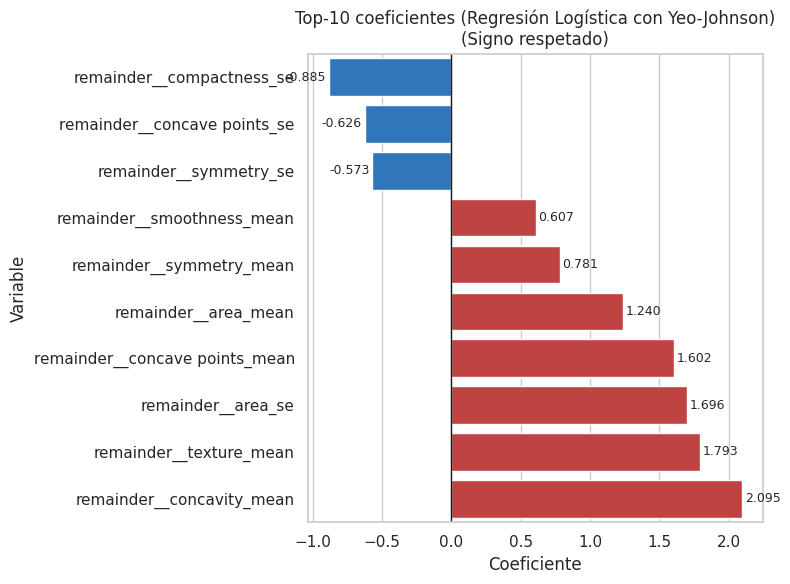

In [9]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid", context="notebook")

try:
    pipe_yeo
except NameError:
    raise NameError(
        "No se encontró 'pipe_yeo'. Asegúrate de ejecutar antes el pipeline "
        "con preprocessing + PowerTransformer(Yeo-Johnson) + LogisticRegression."
    )

clf = pipe_yeo.named_steps["clf"]
if not hasattr(clf, "coef_"):
    if 'X_train' not in globals() or 'y_train' not in globals():
        raise NameError("Faltan X_train/y_train para entrenar 'pipe_yeo'.")
    pipe_yeo.fit(X_train, y_train)
    clf = pipe_yeo.named_steps["clf"]

preproc = pipe_yeo.named_steps["preprocessing"]

try:

    feature_names = preproc.get_feature_names_out(input_features=X_train.columns)
    feature_names = feature_names.tolist()
except Exception:

    n_feats = clf.coef_.shape[1]
    feature_names = [f"feature_{i}" for i in range(n_feats)]
    print("⚠️ No se pudieron recuperar los nombres originales de columnas; se asignan nombres genéricos.")

num_predictors = len(feature_names)
print(f"\n✅ Número de predictores empleados: {num_predictors}")
print("Lista de predictores (primeros 20):", feature_names[:20], "..." if num_predictors > 20 else "")

coefs = clf.coef_.ravel()
coef_df = pd.DataFrame({
    "feature": feature_names,
    "coef": coefs,
    "abs_coef": np.abs(coefs)
})

top10 = coef_df.sort_values("abs_coef", ascending=False).head(10).copy()

print("\n🔝 Top-10 variables más influyentes (por |coef|, con signo):")
print(top10[["feature", "coef"]].to_string(index=False))

top10_plot = top10.sort_values("coef")

colors = top10_plot["coef"].apply(lambda c: "#D32F2F" if c > 0 else "#1976D2").tolist()

plt.figure(figsize=(8, 6))
sns.barplot(
    data=top10_plot,
    x="coef",
    y="feature",
    palette=colors
)
plt.axvline(0, color="k", linewidth=1)
plt.title("Top-10 coeficientes (Regresión Logística con Yeo-Johnson)\n(Signo respetado)")
plt.xlabel("Coeficiente")
plt.ylabel("Variable")

for i, (val) in enumerate(top10_plot["coef"]):
    x_pos = val + (0.02 if val >= 0 else -0.02)
    plt.text(x_pos, i, f"{val:.3f}", va="center",
             ha="left" if val >= 0 else "right", fontsize=9)

plt.tight_layout()
plt.show()

9. Imprime el dataframe de resultados.
* Dibuja la matriz de confusión del mejor modelo. ¿Qué significa cada valor en ella?
* Dibuja la curva ROC del mismo modelo y describe lo que indica sobre su capacidad para distinguir entre clases.

,Model,Recall,Precision,Accuracy
0,Correlation_Clean,Recall,Precision,Accuracy
1,Standard_PCA,Recall,Precision,Accuracy
2,Correlation_Yeo,0.952381,1.0,0.982456


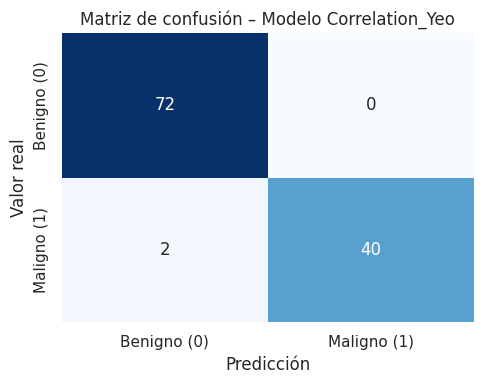

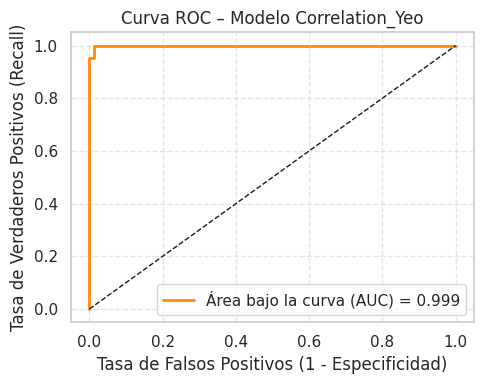

In [10]:
from sklearn.metrics import confusion_matrix, roc_curve, auc, RocCurveDisplay
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np

# 9.1 Imprimir dataframe de resultados (ya generado previamente)
display(results_df)

# 9.2 Matriz de confusión del mejor modelo (Correlation_Yeo)
y_pred_best = pipe_yeo.predict(X_test)
cm = confusion_matrix(y_test, y_pred_best)

plt.figure(figsize=(5,4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', cbar=False,
            xticklabels=['Benigno (0)', 'Maligno (1)'],
            yticklabels=['Benigno (0)', 'Maligno (1)'])
plt.title('Matriz de confusión – Modelo Correlation_Yeo')
plt.xlabel('Predicción')
plt.ylabel('Valor real')
plt.tight_layout()
plt.show()

# 9.3 Curva ROC
y_prob_best = pipe_yeo.predict_proba(X_test)[:,1]
fpr, tpr, thresholds = roc_curve(y_test, y_prob_best)
roc_auc = auc(fpr, tpr)

plt.figure(figsize=(5,4))
plt.plot(fpr, tpr, color='darkorange', lw=2, label=f'Área bajo la curva (AUC) = {roc_auc:.3f}')
plt.plot([0,1],[0,1],'k--',lw=1)
plt.xlabel('Tasa de Falsos Positivos (1 - Especificidad)')
plt.ylabel('Tasa de Verdaderos Positivos (Recall)')
plt.title('Curva ROC – Modelo Correlation_Yeo')
plt.legend(loc='lower right')
plt.grid(True, linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()


El modelo Correlation_Yeo presenta una excelente capacidad discriminativa (AUC ≈ 0.999).
La matriz de confusión muestra alta precisión y sensibilidad: detecta casi todos los casos malignos, con solo 2 falsos negativos.
Esto lo convierte en un modelo muy confiable para diagnóstico médico, donde la prioridad es minimizar los falsos negativos.

10. Grafica la distribución de las probabilidades predichas por clase utilizando histogramas superpuestos, diferenciando la clase Benigno (B) y la clase Maligno (M) con colores.
* ¿Cuál es el umbral (*threshold*) por defecto que utiliza scikit-learn para convertir probabilidades en predicciones binarias?
* En un modelo de diagnóstico médico, ¿cuál consideras que es la métrica más importante?
* ¿Cómo cambiarías (disminuir / aumentar) el *threshold*? ¿Por qué?

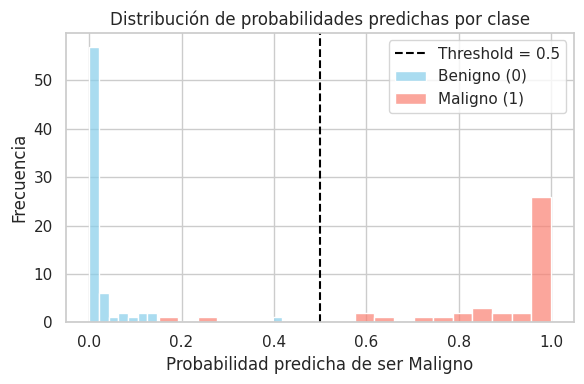

In [11]:
# 10.1 Obtener las probabilidades predichas para la clase Maligno (1)
y_prob = pipe_yeo.predict_proba(X_test)[:, 1]

# 10.2 Crear dataframe con valores reales y probabilidades
prob_df = pd.DataFrame({'y_real': y_test, 'y_prob': y_prob})

# 10.3 Graficar distribución de probabilidades
plt.figure(figsize=(6,4))
sns.histplot(prob_df[prob_df['y_real']==0]['y_prob'], bins=20, color='skyblue', label='Benigno (0)', alpha=0.7)
sns.histplot(prob_df[prob_df['y_real']==1]['y_prob'], bins=20, color='salmon', label='Maligno (1)', alpha=0.7)
plt.axvline(0.5, color='black', linestyle='--', label='Threshold = 0.5')
plt.title('Distribución de probabilidades predichas por clase')
plt.xlabel('Probabilidad predicha de ser Maligno')
plt.ylabel('Frecuencia')
plt.legend()
plt.tight_layout()
plt.show()

El umbral por defecto de scikit-learn es 0.5, lo que significa que el modelo clasifica como maligno (1) cuando la probabilidad ≥ 0.5.
En el contexto médico, la métrica más importante es el recall (sensibilidad), ya que detectar un tumor maligno es crítico.
Por ello, si se desea priorizar la detección de casos malignos, se podría disminuir el umbral (por ejemplo a 0.3), aumentando la sensibilidad a costa de una ligera reducción en precisión.